<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Constant003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

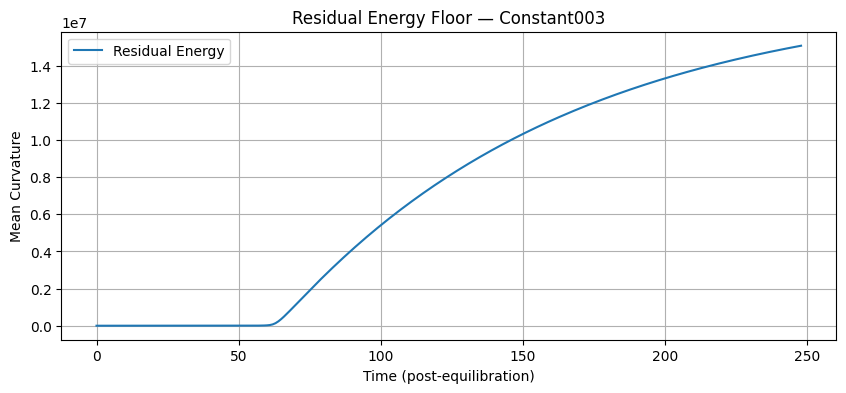

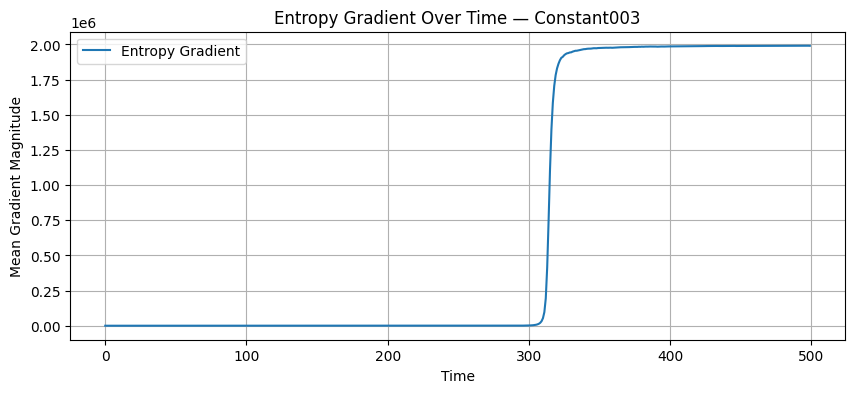

In [1]:
# Constant003 — High ξ Imbalance
import numpy as np, matplotlib.pyplot as plt

size, steps = 100, 500
ξ, noise_amp, damping = 0.09, 1e-3, 0.01
sequestration_enabled = True

entropy = np.random.rand(size, size)
curvature = np.zeros((size, size))
residual_energy, entropy_gradients = [], []

for t in range(steps):
    noise = noise_amp * np.random.randn(size, size)
    grad_x, grad_y = np.gradient(entropy)
    grad_x = np.clip(grad_x, -1e3, 1e3)
    grad_y = np.clip(grad_y, -1e3, 1e3)
    flow = grad_x**2 + grad_y**2
    entropy_gradients.append(np.nanmean(flow))
    curvature += ξ * flow - damping * curvature + noise
    curvature = np.nan_to_num(curvature, nan=0.0, posinf=1e6, neginf=0.0)
    if sequestration_enabled:
        threshold = np.nanpercentile(curvature, 95)
        curvature = np.clip(curvature, 0, threshold)
    entropy += curvature * damping
    if t > steps // 2:
        residual_energy.append(np.nanmean(curvature))

plt.figure(figsize=(10, 4))
plt.plot(residual_energy, label='Residual Energy')
plt.title("Residual Energy Floor — Constant003")
plt.xlabel("Time (post-equilibration)")
plt.ylabel("Mean Curvature")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(entropy_gradients, label='Entropy Gradient')
plt.title("Entropy Gradient Over Time — Constant003")
plt.xlabel("Time")
plt.ylabel("Mean Gradient Magnitude")
plt.grid(True)
plt.legend()
plt.show()
